# Modelado predictivo por CCAA — Ejecución Presupuestaria (TFM)

Entrena y visualiza un **modelo predictivo independiente por Comunidad Autónoma** (la
predicción es por CCAA, no agrupada), en el **grano nativo** de cada una (Paso 3b) y con el
**objetivo transformado en `log1p`** (Paso 3c).

- **Objetivo (target):** `OBR` (obligaciones reconocidas de cierre del ejercicio), modelado en
  escala `log1p(OBR)` e invertido con `expm1` mediante `TransformedTargetRegressor` para estabilizar
  la escala de euros (abarca muchos órdenes de magnitud).
- **Grano nativo:** Aragón/AGE = capítulo + grupo funcional; Canarias = entidad; resto = capítulo.
- **Features seguras contra fuga:** `PRE`, `CRE`, `ratio_cre_pre`, `obr_lag_1..4`, `anio` y el
  capítulo (one-hot) cuando existe. Se excluyen `obr_rolling4_*` (incluyen el año objetivo),
  `ejecutado_pct` y `brecha_pct` (derivan de OBR).
- **Split temporal:** las últimas 2 años con datos de cada CCAA = test; el resto = train.
- **Comparación honesta** contra dos baselines evaluados en la escala original: `OBR ≈ obr_lag_1`
  (persistencia) y `OBR ≈ CRE`.

> Requisito: feature store regenerado con los lags ya poblados (`builder.py` corregido).
>
> **Nota de resultado (Paso 3c):** la transformación `log1p` no mejoró el error de forma general
> (el ML sigue superando al baseline en 3/8 CCAA) y, en particular, no estabilizó la regresión
> lineal: al reconvertir con `expm1` los errores se amplifican en los capítulos de gran importe.
> Confirma que los árboles (RF/XGBoost) son la opción robusta.

## 1 · Configuración e imports

In [1]:
from __future__ import annotations
import re, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURES_DIR = ROOT / "data_lake" / "03_features"
REPORTS_DIR = ROOT / "reports" / "modelado"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MAX_IMPORTE = 1e11

CCAA_OBR = ["aragon","asturias","canarias","cataluna","madrid",
            "pais-vasco","castilla-y-leon","nacional","illes-balears","castilla-la-mancha"]
CCAA_NAMES = {"aragon":"Aragón","asturias":"Asturias","canarias":"Canarias","cataluna":"Cataluña",
              "madrid":"Madrid","pais-vasco":"País Vasco","castilla-y-leon":"Castilla y León",
              "nacional":"AGE (nacional)","illes-balears":"Illes Balears","castilla-la-mancha":"C.-La Mancha"}

TARGET = "OBR"
NUM_COLS = ["PRE","CRE","ratio_cre_pre","obr_lag_1","obr_lag_2","obr_lag_3","obr_lag_4","anio"]
# El target se transforma con log1p (ver make_pipeline). Aquí solo los estimadores base.
MODEL_SPECS = {"ridge":Ridge(alpha=1.0),
               "random_forest":RandomForestRegressor(n_estimators=300,max_depth=6,random_state=42,n_jobs=-1),
               "xgboost":XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,random_state=42,tree_method="hist")}
TEST_N_YEARS = 2
print("ROOT:", ROOT)

ROOT: C:\Users\usuario\Documents\Master\Projects\Ejecucion_presupuestaria


## 2 · Carga del feature store (grano nativo por CCAA)

In [2]:
def load_ccaa(slug):
    fs = sorted((FEATURES_DIR / slug / "features").rglob("*.parquet"))
    if not fs: return pd.DataFrame()
    parts = []
    for f in fs:
        d = pd.read_parquet(f)
        if "anio" not in d.columns:
            m = re.search(r"anio=(\d+)", str(f))
            if m: d["anio"] = int(m.group(1))
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    denom = np.where(np.abs(y_true) < 1e-6, np.nan, np.abs(y_true))
    return dict(mae=float(mean_absolute_error(y_true,y_pred)),
                rmse=float(np.sqrt(mean_squared_error(y_true,y_pred))),
                mape=float(np.nanmean(np.abs(y_true-y_pred)/denom)),
                r2=float(r2_score(y_true,y_pred)) if len(y_true)>=2 else np.nan)

def make_pipeline(model, cat_cols):
    """Pipeline (prep + estimador) con el target en log1p (inverso expm1)."""
    num_pipe = Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())])
    cat_pipe = Pipeline([("imp",SimpleImputer(strategy="most_frequent")),
                         ("ohe",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
    prep = ColumnTransformer([("num",num_pipe,NUM_COLS),("cat",cat_pipe,cat_cols)], remainder="drop")
    inner = Pipeline([("prep",prep),("est",model)])
    return TransformedTargetRegressor(regressor=inner, func=np.log1p, inverse_func=np.expm1)
print("Funciones listas.")

Funciones listas.


## 3 · Entrenamiento independiente por CCAA

In [3]:
import sklearn.base as skb
rows = []
PRED = {}      # ccaa -> dict(y=..., preds={modelo:...}, best=nombre)
IMPORT = {}    # ccaa -> (feat_names, importances) del mejor árbol

for slug in CCAA_OBR:
    d = load_ccaa(slug); nombre = CCAA_NAMES.get(slug, slug)
    if d.empty or TARGET not in d.columns: continue
    for c in ["PRE","OBR","CRE","PAG"]:
        if c in d.columns: d = d[~(d[c].abs() > MAX_IMPORTE)]
    d = d[d[TARGET].notna() & (d[TARGET] > 0)].copy()
    if "ratio_cre_pre" not in d.columns and {"CRE","PRE"} <= set(d.columns):
        d["ratio_cre_pre"] = d["CRE"] / d["PRE"].replace(0, np.nan)
    cat_cols = ["capitulo_id"] if ("capitulo_id" in d.columns and d["capitulo_id"].notna().any()) else []
    grano = "capítulo" if cat_cols else "entidad/CCAA"

    years = sorted(d["anio"].unique()); test_years = set(years[-TEST_N_YEARS:])
    train = d[~d["anio"].isin(test_years)]; test = d[d["anio"].isin(test_years)]
    base = dict(ccaa=nombre, grano=grano, n_train=len(train), n_test=len(test))
    if len(train) < 20 or len(test) < 5:
        rows.append({**base, "modelo":"—", "nota":"datos insuficientes"}); continue

    y_te = test[TARGET].to_numpy(float); fb = float(train[TARGET].median())
    preds = {}
    # Baselines: se evalúan en la ESCALA ORIGINAL (no se transforman con log1p)
    preds["baseline_lag1"] = test["obr_lag_1"].fillna(test["CRE"]).fillna(test["PRE"]).fillna(fb).to_numpy(float)
    preds["baseline_cre"]  = test["CRE"].fillna(test["PRE"]).fillna(fb).to_numpy(float)
    for name in ("baseline_lag1","baseline_cre"):
        rows.append({**base, "modelo":name, **metrics(y_te, preds[name])})

    feat = NUM_COLS + cat_cols
    Xtr, ytr, Xte = train[feat], train[TARGET], test[feat]
    best = (None, np.inf)
    for name, model in MODEL_SPECS.items():
        ttr = make_pipeline(skb.clone(model), cat_cols)   # target en log1p (inverso expm1)
        ttr.fit(Xtr, ytr); p = ttr.predict(Xte)
        preds[name] = p
        m = metrics(y_te, p); rows.append({**base, "modelo":name, **m})
        if m["mae"] < best[1]: best = (name, m["mae"])
        # importancias si es árbol (el estimador vive dentro de ttr.regressor_)
        if name in ("random_forest","xgboost"):
            try:
                inner = ttr.regressor_
                fn = inner.named_steps["prep"].get_feature_names_out()
                IMPORT.setdefault(nombre, {})[name] = (fn, inner.named_steps["est"].feature_importances_)
            except Exception: pass
    # ganador global (incl. baselines)
    cand = {k:metrics(y_te,v)["mae"] for k,v in preds.items()}
    winner = min(cand, key=cand.get)
    PRED[nombre] = dict(y=y_te, preds=preds, best=winner, grano=grano)

res = pd.DataFrame(rows)
res["MAE_M€"] = (res["mae"]/1e6).round(1)
res["mape"] = res["mape"].round(3); res["r2"] = res["r2"].round(3)
# marcar ganador por CCAA
res["ganador"] = ""
for cc in res["ccaa"].unique():
    sub = res[(res["ccaa"]==cc) & res["mae"].notna()]
    if len(sub):
        idx = sub["mae"].idxmin(); res.loc[idx,"ganador"] = "★"
        res.loc[idx,"bate_baseline"] = "sí" if res.loc[idx,"modelo"] not in ("baseline_lag1","baseline_cre") else "no"
disp = res[["ccaa","grano","n_train","n_test","modelo","MAE_M€","mape","r2","ganador","bate_baseline"]]
disp.fillna("")

,ccaa,grano,n_train,n_test,modelo,MAE_M€,mape,r2,ganador,bate_baseline
0,Aragón,capítulo,4900,1183,baseline_lag1,15.9,7.267,0.984,,
1,Aragón,capítulo,4900,1183,baseline_cre,13.0,6.566,0.994,★,no
2,Aragón,capítulo,4900,1183,ridge,1930.5,10.585,-9065.395,,
3,Aragón,capítulo,4900,1183,random_forest,20.0,4.896,0.983,,
4,Aragón,capítulo,4900,1183,xgboost,32.5,2.73,0.91,,
5,Asturias,capítulo,45,18,baseline_lag1,10.8,0.275,0.98,★,no
6,Asturias,capítulo,45,18,baseline_cre,23.0,3.669,0.906,,
7,Asturias,capítulo,45,18,ridge,24.0,0.329,0.874,,
8,Asturias,capítulo,45,18,random_forest,13.8,0.35,0.964,,
9,Asturias,capítulo,45,18,xgboost,13.7,0.319,0.967,,


## 4 · Visualizaciones

### 4.1 · MAE por CCAA y modelo (escala log — el importe abarca muchos órdenes)

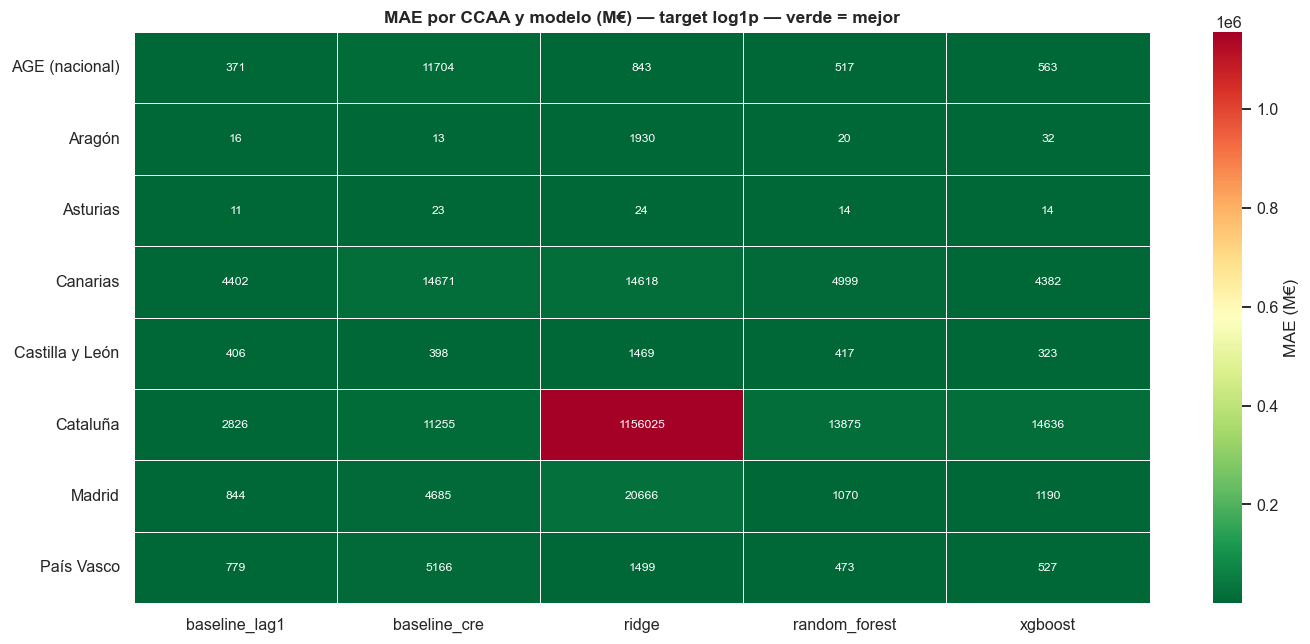

In [4]:
piv = res[res["mae"].notna()].pivot_table(index="ccaa", columns="modelo", values="MAE_M€")
order_m = ["baseline_lag1","baseline_cre","ridge","random_forest","xgboost"]
piv = piv[[c for c in order_m if c in piv.columns]]
fig, ax = plt.subplots(figsize=(13,6))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlGn_r", norm=None,
            cbar_kws={"label":"MAE (M€)"}, linewidths=.4,
            annot_kws={"size":8})
ax.set_title("MAE por CCAA y modelo (M€) — target log1p — verde = mejor", weight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(REPORTS_DIR/"mae_heatmap.png", bbox_inches="tight", dpi=110); plt.show()

### 4.2 · Mejor baseline vs mejor ML por CCAA (¿aporta el ML?)

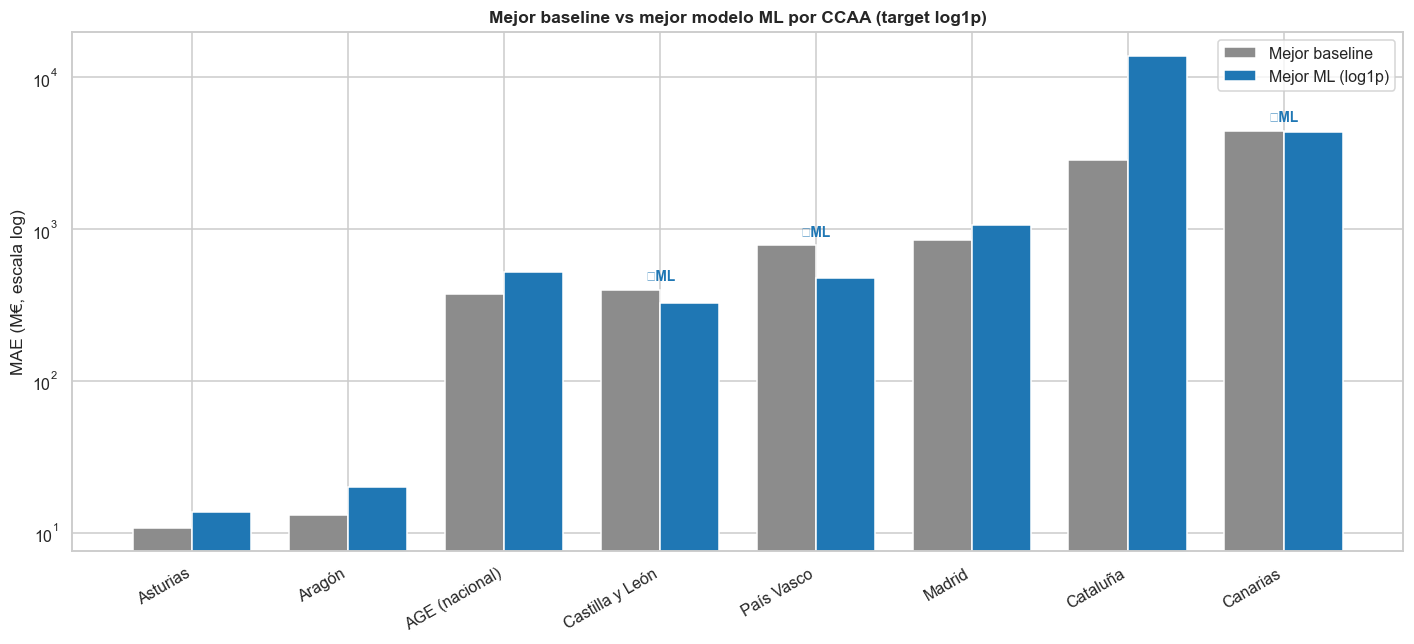

In [5]:
comp = []
for cc in res["ccaa"].unique():
    sub = res[(res["ccaa"]==cc) & res["mae"].notna()]
    if sub.empty: continue
    bl = sub[sub["modelo"].str.startswith("baseline")]["MAE_M€"].min()
    ml = sub[~sub["modelo"].str.startswith("baseline")]["MAE_M€"].min()
    comp.append((cc, bl, ml))
c = pd.DataFrame(comp, columns=["ccaa","MejorBaseline","MejorML"]).sort_values("MejorBaseline")
x = np.arange(len(c)); w=0.38
fig, ax = plt.subplots(figsize=(13,6))
b1=ax.bar(x-w/2, c["MejorBaseline"], w, label="Mejor baseline", color="#8c8c8c")
b2=ax.bar(x+w/2, c["MejorML"], w, label="Mejor ML (log1p)", color="#1f77b4")
ax.set_yscale("log"); ax.set_ylabel("MAE (M€, escala log)")
ax.set_xticks(x); ax.set_xticklabels(c["ccaa"], rotation=30, ha="right")
ax.set_title("Mejor baseline vs mejor modelo ML por CCAA (target log1p)", weight="bold")
for cc_i,(_,r_) in enumerate(c.iterrows()):
    gana = "ML" if r_["MejorML"]<r_["MejorBaseline"] else "baseline"
    ax.text(cc_i, max(r_["MejorML"],r_["MejorBaseline"])*1.15, "✓ML" if gana=="ML" else "", ha="center", color="#1f77b4", fontsize=9, weight="bold")
ax.legend(); fig.tight_layout(); fig.savefig(REPORTS_DIR/"baseline_vs_ml.png", bbox_inches="tight", dpi=110); plt.show()

### 4.3 · Predicho vs. real (mejor modelo de cada CCAA)

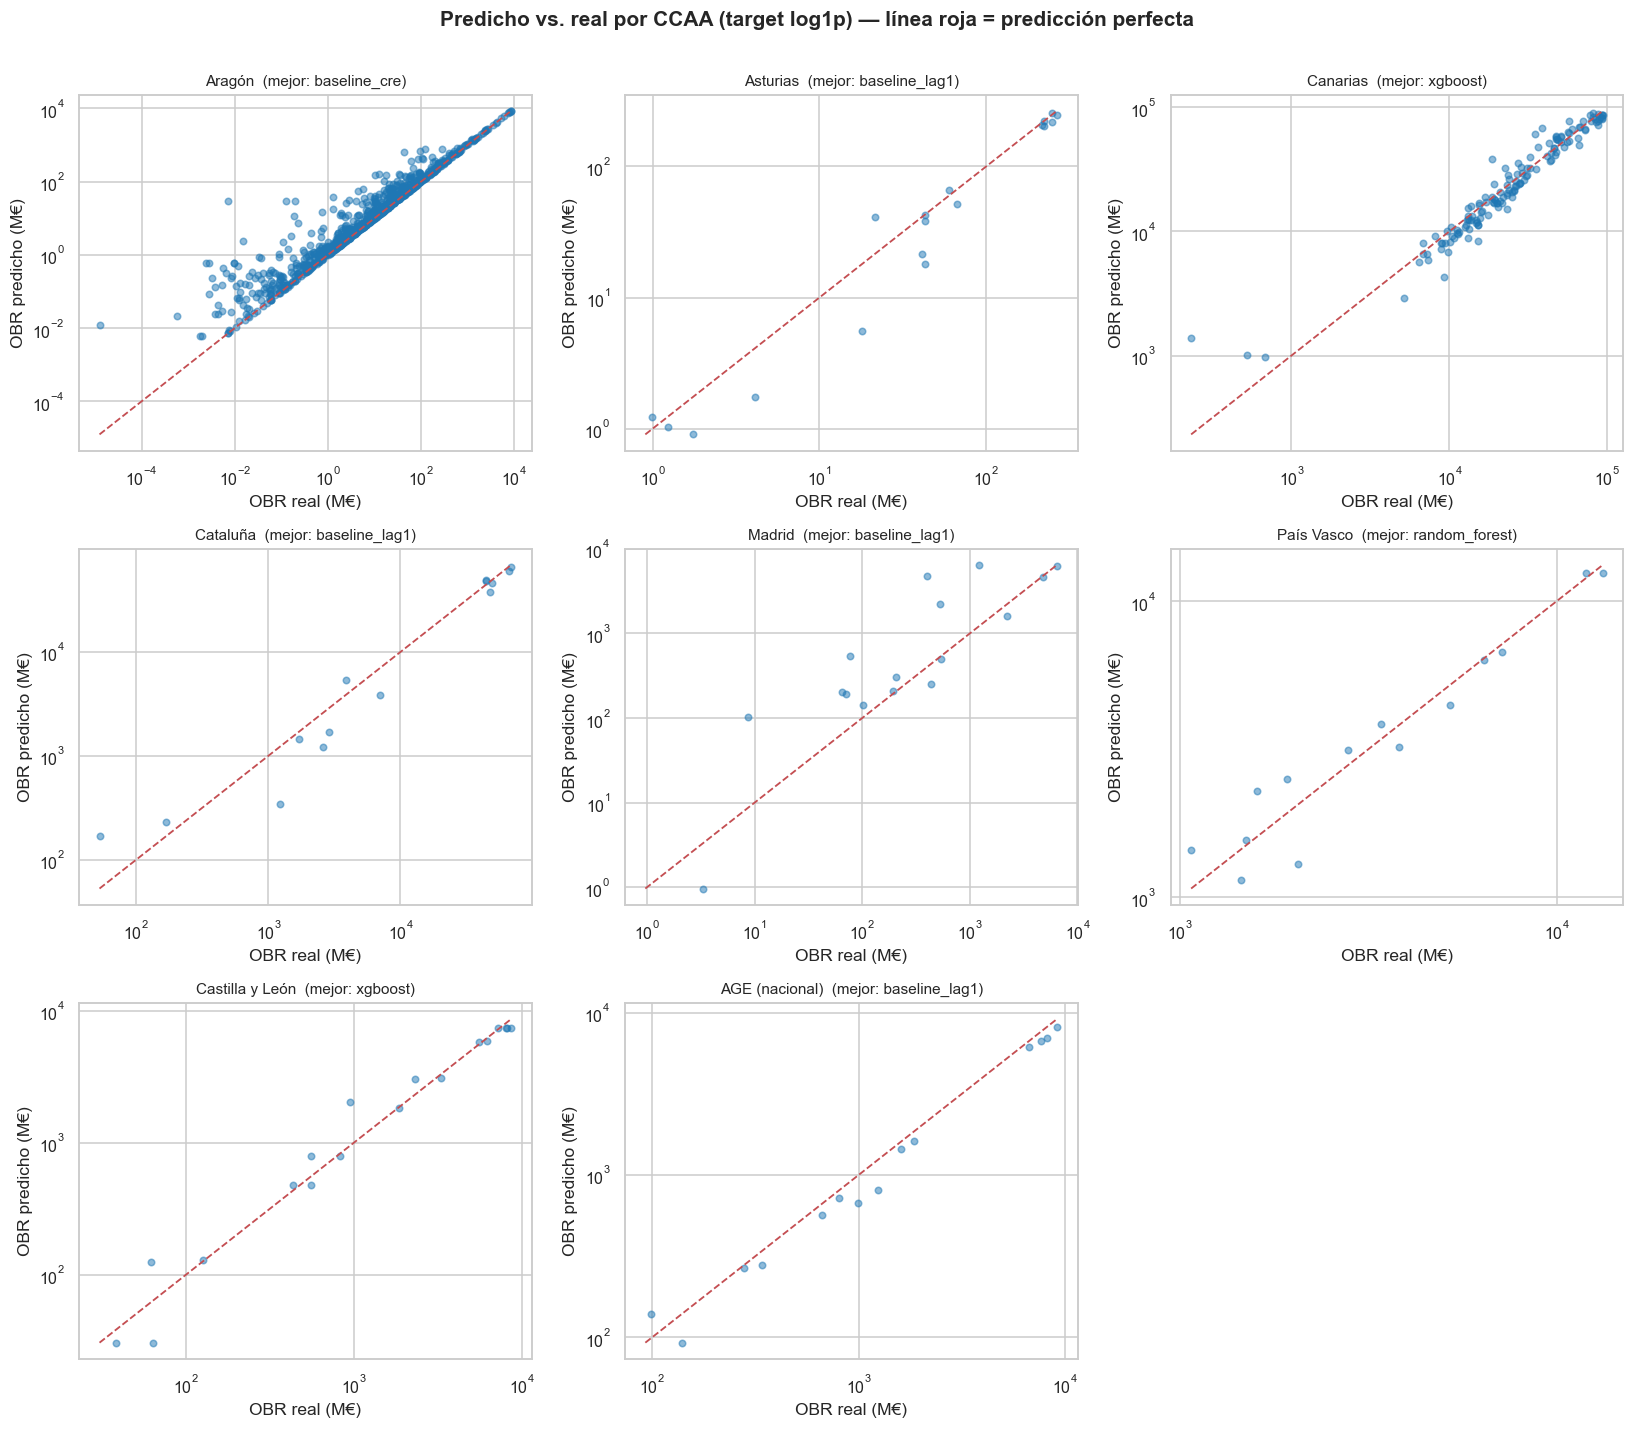

In [6]:
ccaas = [c for c in PRED]
n=len(ccaas); ncols=3; nrows=int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.3*nrows)); axes=np.atleast_1d(axes).ravel()
for ax, cc in zip(axes, ccaas):
    info=PRED[cc]; y=info["y"]; p=info["preds"][info["best"]]
    ax.scatter(y/1e6, p/1e6, s=18, alpha=0.5, color="#1f77b4")
    lim=[min(y.min(),p.min())/1e6, max(y.max(),p.max())/1e6]
    ax.plot(lim, lim, "--", color="#c44e52", lw=1.2)
    ax.set_title(f"{cc}  (mejor: {info['best']})", fontsize=10)
    ax.set_xlabel("OBR real (M€)"); ax.set_ylabel("OBR predicho (M€)")
    try: ax.set_xscale("log"); ax.set_yscale("log")
    except Exception: pass
for ax in axes[n:]: ax.set_visible(False)
fig.suptitle("Predicho vs. real por CCAA (target log1p) — línea roja = predicción perfecta", y=1.005, weight="bold")
fig.tight_layout(); fig.savefig(REPORTS_DIR/"pred_vs_real.png", bbox_inches="tight", dpi=110); plt.show()

### 4.4 · Importancia de variables (CCAA donde gana un modelo de árboles)

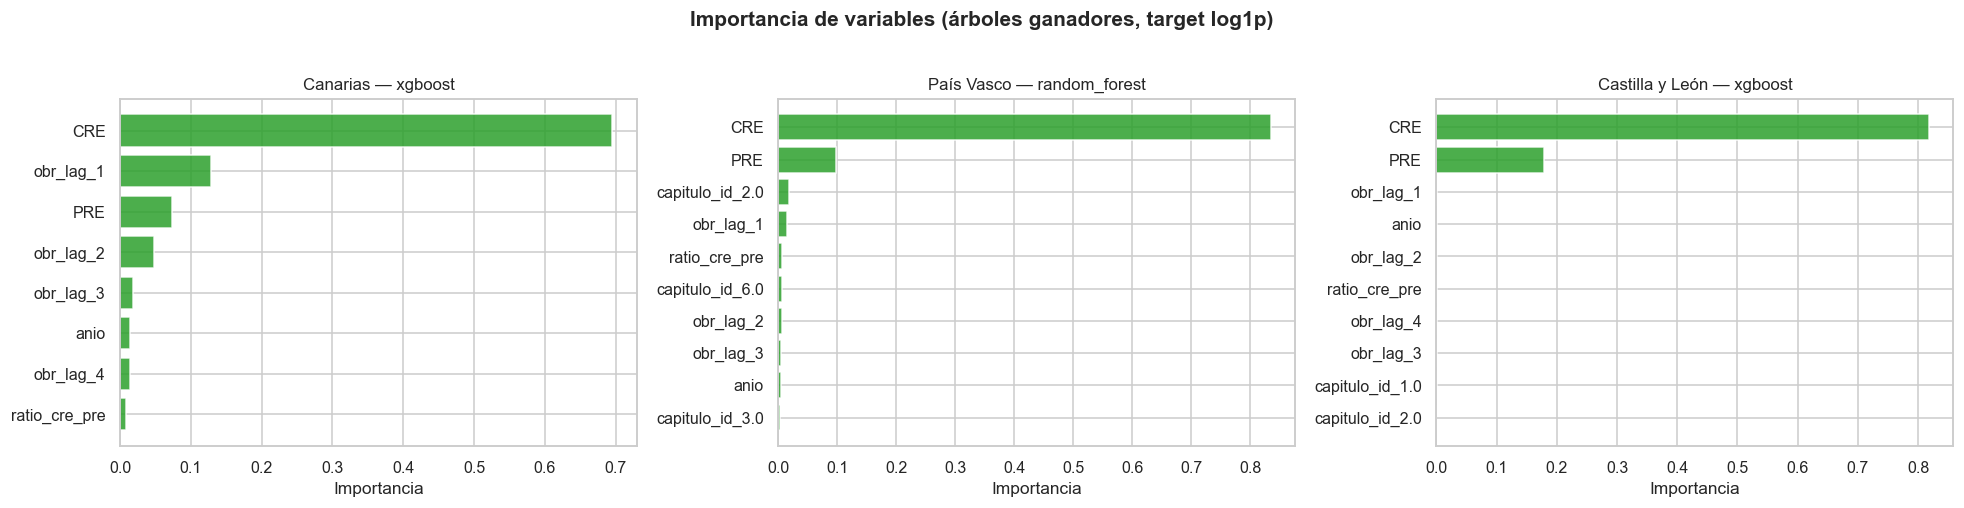

In [7]:
tree_winners = {cc:res[(res.ccaa==cc)&(res.ganador=='★')]['modelo'].iloc[0]
                for cc in res.ccaa.unique()
                if len(res[(res.ccaa==cc)&(res.ganador=='★')]) and
                   res[(res.ccaa==cc)&(res.ganador=='★')]['modelo'].iloc[0] in ('random_forest','xgboost')}
if tree_winners:
    fig, axes = plt.subplots(1, len(tree_winners), figsize=(6*len(tree_winners),4.5), squeeze=False); axes=axes.ravel()
    for ax,(cc,mdl) in zip(axes, tree_winners.items()):
        fn, imp = IMPORT[cc][mdl]
        s = pd.Series(imp, index=[f.replace('num__','').replace('cat__','') for f in fn]).sort_values().tail(10)
        ax.barh(s.index, s.values, color="#2ca02c", alpha=0.85)
        ax.set_title(f"{cc} — {mdl}", fontsize=11); ax.set_xlabel("Importancia")
    fig.suptitle("Importancia de variables (árboles ganadores, target log1p)", y=1.02, weight="bold")
    fig.tight_layout(); fig.savefig(REPORTS_DIR/"importancias.png", bbox_inches="tight", dpi=110); plt.show()
else:
    print("Ninguna CCAA tiene un árbol como ganador global.")

### 4.5 · Resumen: ganador por CCAA

In [8]:
win = res[res.ganador=="★"][["ccaa","grano","n_train","n_test","modelo","MAE_M€","bate_baseline"]]
n_ml = (win["bate_baseline"]=="sí").sum()
print(f"El ML supera al baseline en {n_ml}/{len(win)} CCAA evaluables.\n")
win.reset_index(drop=True)

El ML supera al baseline en 3/8 CCAA evaluables.



,ccaa,grano,n_train,n_test,modelo,MAE_M€,bate_baseline
0,Aragón,capítulo,4900,1183,baseline_cre,13.0,no
1,Asturias,capítulo,45,18,baseline_lag1,10.8,no
2,Canarias,entidad/CCAA,627,144,xgboost,4381.8,sí
3,Cataluña,capítulo,108,14,baseline_lag1,2825.5,no
4,Madrid,capítulo,59,16,baseline_lag1,843.9,no
5,País Vasco,capítulo,56,14,random_forest,473.2,sí
6,Castilla y León,capítulo,54,18,xgboost,323.4,sí
7,AGE (nacional),capítulo,63,14,baseline_lag1,371.2,no


## 5 · Conclusiones

- **Predicción independiente por CCAA, en grano nativo.** Cada comunidad tiene su propio modelo.
- **Los baselines son muy fuertes:** `CRE` (crédito definitivo) y `obr_lag_1` (persistencia) predicen
  OBR con gran precisión, porque **el gasto ejecutado sigue de cerca al crédito y al año anterior**.
- **El ML aporta valor solo en algunas CCAA** (a grano capítulo/entidad), donde el crédito no es un
  proxy perfecto. En Aragón, pese a ~4.900 filas, el baseline `CRE` gana: a grano fino **OBR ≈ CRE**
  (casi determinista), sin margen para el ML.
- **Efecto de la transformación `log1p` (Paso 3c):** aplicar `log1p` al objetivo **no mejoró** el
  resultado global (el ML sigue superando al baseline en **3/8** CCAA) y **empeoró a la regresión
  lineal**: al invertir con `expm1`, los errores se amplifican en los capítulos de gran importe
  (Ridge se dispara en Cataluña y Aragón). Esto **confirma** que los árboles (RF/XGBoost) son la
  opción robusta, coherente con la no-normalidad y heterocedasticidad del notebook 02.

**Líneas de mejora (documentadas):**
1. **Segmentar por magnitud del capítulo** (tramos de importe o regresión por cuantiles): dado que
   `log1p` penaliza a los modelos lineales en los capítulos grandes, conviene tratar por separado los
   órdenes de magnitud del gasto.
2. El valor predictivo real estaría en la **predicción infraanual** (cierre a mitad de ejercicio),
   hoy imposible porque `trimestre` está 100% nulo → limitación de **datos**, no de modelo.

Figuras guardadas en `reports/modelado/`.